# 01 — Sensor Overview & Dataset Exploration

This notebook provides a first look at the **AQUINAS dataset**:

- Load a monthly dataset (SET1) and inspect the 48 sensors
- Read a single event record and plot the raw waveform
- Visualise all 48 sensors side-by-side for a chosen event
- Overlay all sensor waveforms on one plot

**Attribution:** The original exploratory analysis was developed by
`Zhenkun Li`. This notebook is a cleaned and restructured version
using the `aquinas_toolkit` package.

In [1]:
from aquinas_toolkit import AquinasReader, plot_waveform, plot_sensor_grid, plot_sensor_overlay
from aquinas_toolkit.utils import find_dataset_root

## Load a dataset

Point `dataset_dir` at any of the five monthly SET folders.
The dataset is not committed to git -- place it at
`AQUINAS_DATASET/` in the repo root.

In [2]:
dataset_root = find_dataset_root()
dataset_dir = dataset_root / "AQUINAS_SET1_2022_07"
reader = AquinasReader(dataset_dir)

print(f"Dataset: {reader.set_name}")
print(f"\nSensor summary ({len(reader.table_files)} sensors):")
reader.summary()

Dataset: AQUINAS_SET1_2022_07

Sensor summary (48 sensors):


,dataset,sensor_name,table_file,sensor_dir_exists,sensor_dir
0,AQUINAS_SET1_2022_07,NEW_S1_DO_INF_STR,TABLE_NEW_S1_DO_INF_STR_SET1.json,True,C:\Users\murat\Documents\GitHub\EWSHM_Competit...
1,AQUINAS_SET1_2022_07,NEW_S1_DO_INT_ACC_Y,TABLE_NEW_S1_DO_INT_ACC_Y_SET1.json,True,C:\Users\murat\Documents\GitHub\EWSHM_Competit...
2,AQUINAS_SET1_2022_07,NEW_S1_DO_INT_ACC_Z,TABLE_NEW_S1_DO_INT_ACC_Z_SET1.json,True,C:\Users\murat\Documents\GitHub\EWSHM_Competit...
3,AQUINAS_SET1_2022_07,NEW_S1_DO_MID_ACC_Y,TABLE_NEW_S1_DO_MID_ACC_Y_SET1.json,True,C:\Users\murat\Documents\GitHub\EWSHM_Competit...
4,AQUINAS_SET1_2022_07,NEW_S1_DO_MID_ACC_Z,TABLE_NEW_S1_DO_MID_ACC_Z_SET1.json,True,C:\Users\murat\Documents\GitHub\EWSHM_Competit...
5,AQUINAS_SET1_2022_07,NEW_S1_DO_SHE_STR,TABLE_NEW_S1_DO_SHE_STR_SET1.json,True,C:\Users\murat\Documents\GitHub\EWSHM_Competit...
6,AQUINAS_SET1_2022_07,NEW_S1_DO_SUP_STR,TABLE_NEW_S1_DO_SUP_STR_SET1.json,True,C:\Users\murat\Documents\GitHub\EWSHM_Competit...
7,AQUINAS_SET1_2022_07,NEW_S1_UP_INF_STR,TABLE_NEW_S1_UP_INF_STR_SET1.json,True,C:\Users\murat\Documents\GitHub\EWSHM_Competit...
8,AQUINAS_SET1_2022_07,NEW_S1_UP_INT_ACC_Z,TABLE_NEW_S1_UP_INT_ACC_Z_SET1.json,True,C:\Users\murat\Documents\GitHub\EWSHM_Competit...
9,AQUINAS_SET1_2022_07,NEW_S1_UP_MID_ACC_Z,TABLE_NEW_S1_UP_MID_ACC_Z_SET1.json,True,C:\Users\murat\Documents\GitHub\EWSHM_Competit...


## Inspect a single sensor & event

Pick one sensor and load the first event to see what the raw
waveform looks like.

In [3]:
sensors = reader.list_sensor_names()
print(f"Total sensors: {len(sensors)}")

# Choose a sensor and event index
sensor = sensors[0]
event_idx = 0

index_df = reader.load_index_table(sensor)
print(f"\nSensor: {sensor}")
print(f"Total events: {len(index_df)}")

meta, waveform = reader.read_record(sensor_name=sensor, row_index=event_idx)

print("\nEvent metadata:")
print(meta)
print(f"\nWaveform shape: {waveform.shape}")
waveform.head()

Total sensors: 48

Sensor: NEW_S1_DO_INF_STR
Total events: 3633

Event metadata:
Record_UID                              9133
File           NEW_S1_DO_INF_STR_SET1_1.json
Start_Row                                  1
End_Row                                 1425
Start_Time               2022-07-01 02:39:01
End_Time                 2022-07-01 02:39:16
Duration                                14.3
Start_Value                          -0.2566
End_Value                            -0.2569
Diff_Value                           -0.0003
Min_Value                            -0.2595
Max_Value                            -0.2478
Mean_Value                           -0.2568
Range                                 0.0117
Temperature                          12.4773
Name: 0, dtype: object

Waveform shape: (1425, 2)


,timestamp,NEW_S1_DO_INF_STR
0,2022-07-01 02:39:01.773,-0.2566
1,2022-07-01 02:39:01.783,-0.2562
2,2022-07-01 02:39:01.793,-0.2564
3,2022-07-01 02:39:01.803,-0.2568
4,2022-07-01 02:39:01.813,-0.2557


<Axes: title={'center': 'NEW_S1_DO_INF_STR -- event 0'}, xlabel='Sample (100 Hz)', ylabel='Response'>

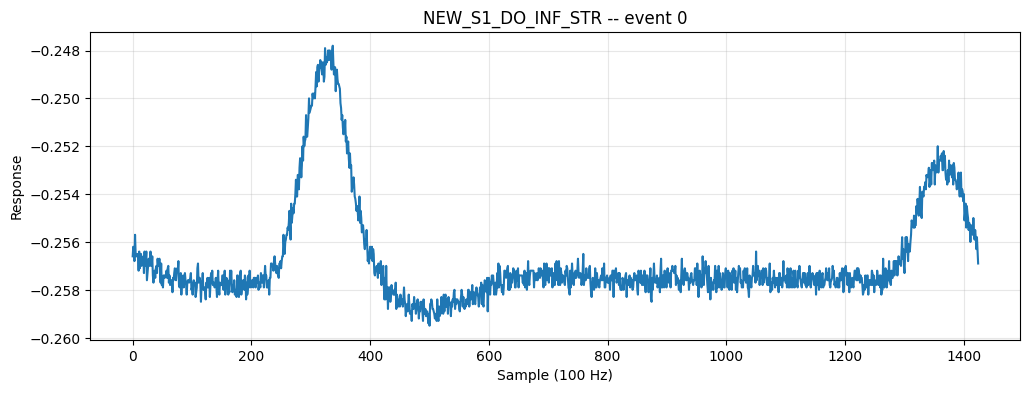

In [4]:
meta, waveform = reader.read_record(sensor, row_index=event_idx)
plot_waveform(waveform, title=f"{sensor} -- event {event_idx}")

## All 48 sensors -- grid view

Plot the same event index across every sensor to compare
acceleration and strain responses.

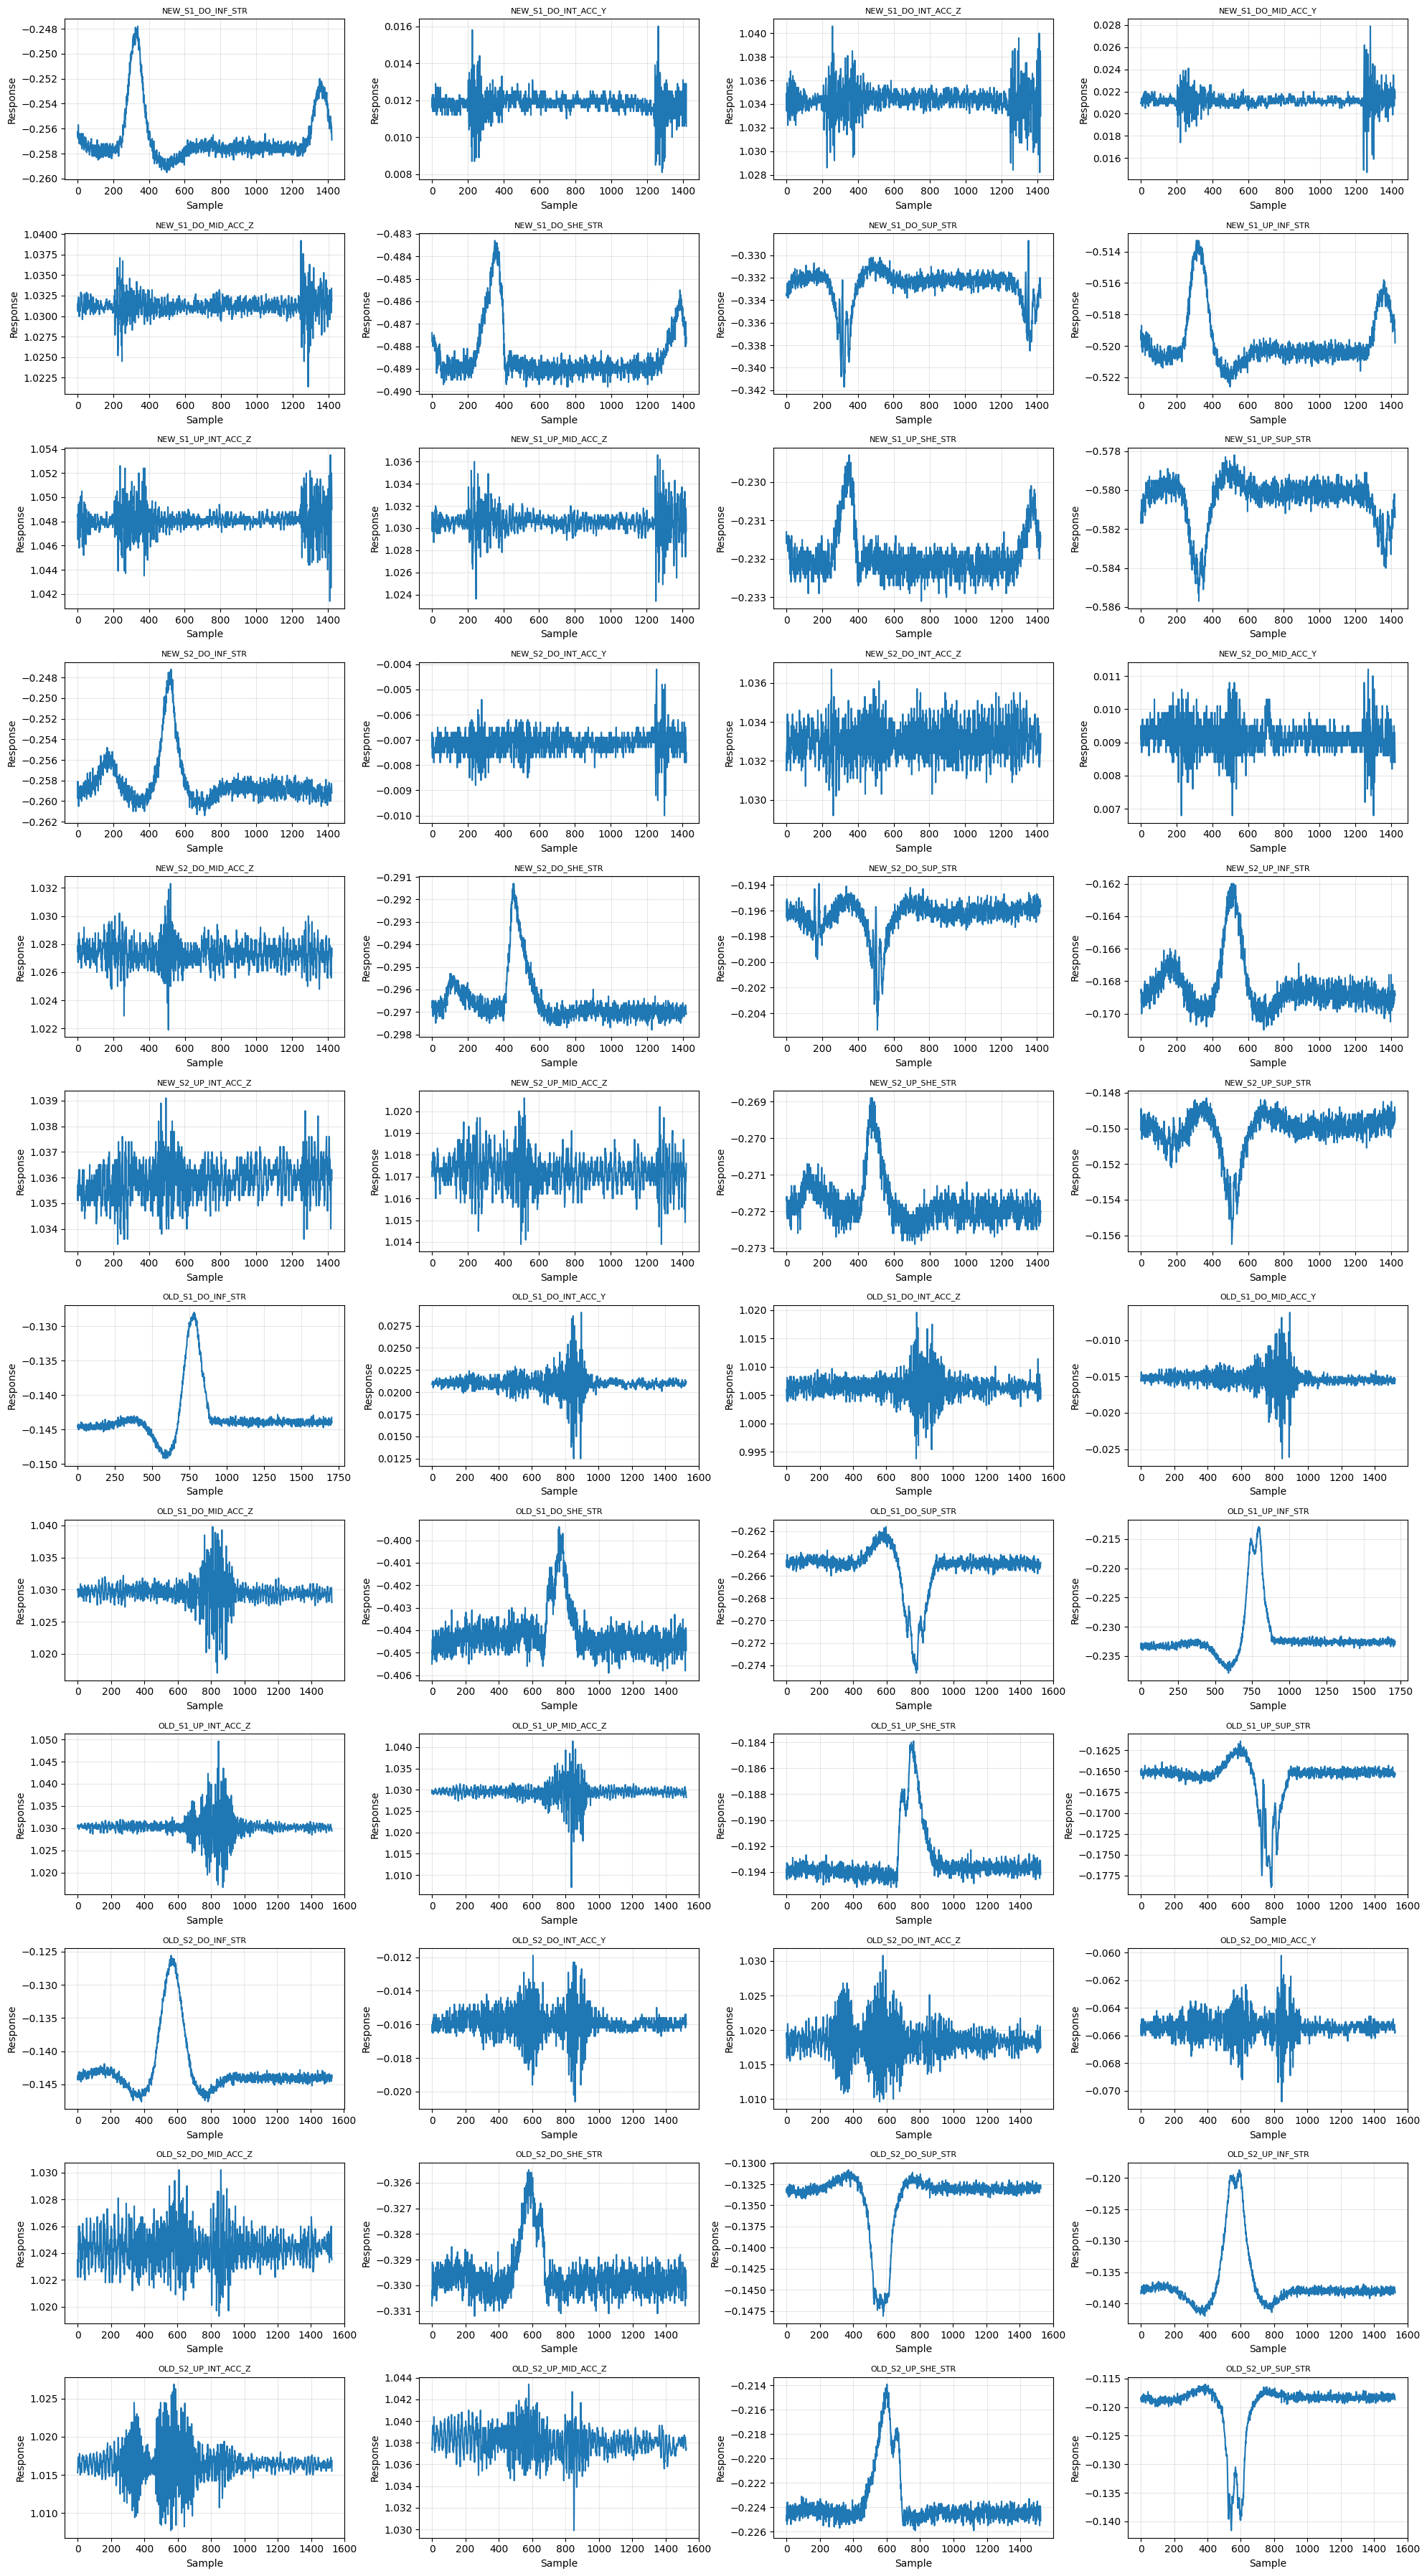

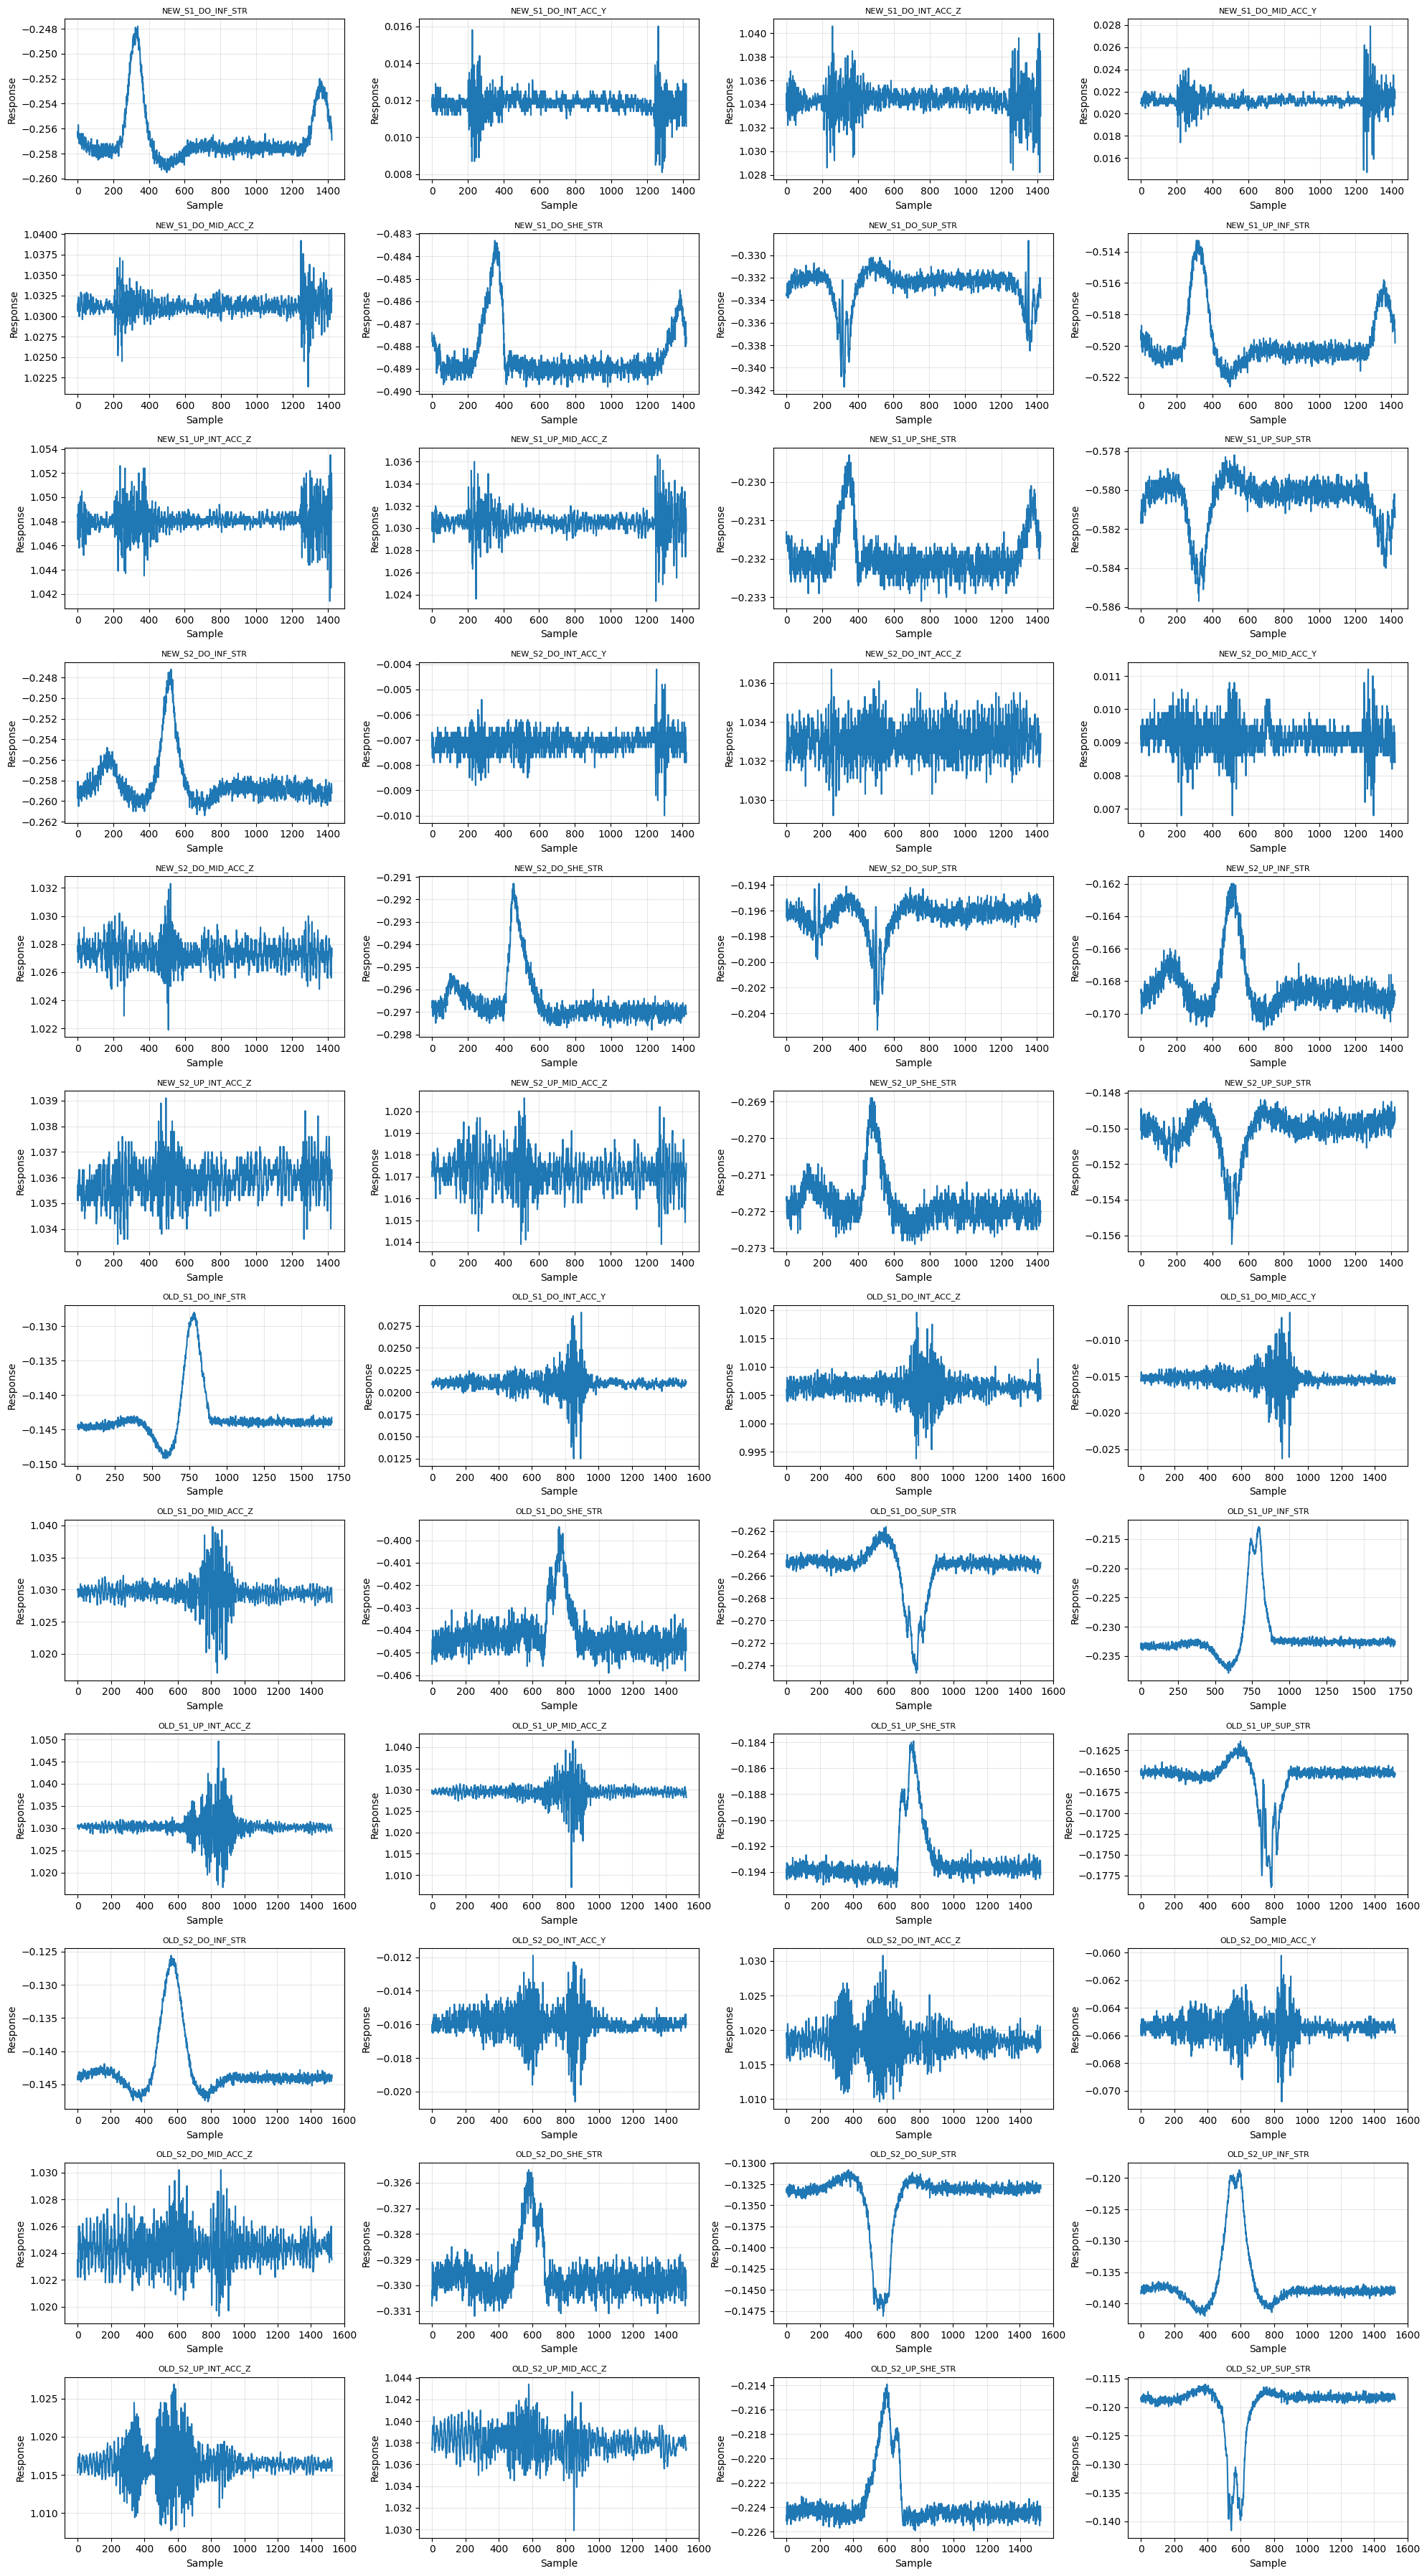

In [5]:
plot_sensor_grid(reader, event_idx=0)

## All sensors -- overlay view

Overlay every sensor's waveform on a single plot to see
relative magnitudes and timing.

<Axes: title={'center': 'All sensors -- event 0'}, xlabel='Sample (100 Hz)', ylabel='Response'>

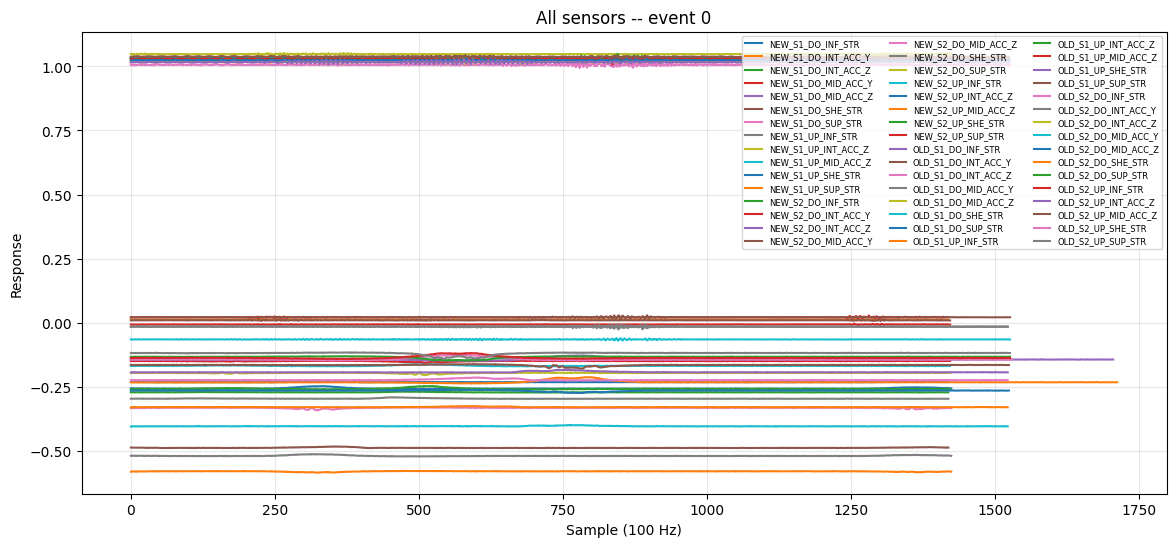

In [6]:
plot_sensor_overlay(reader, event_idx=0)